In [2]:
!pip install seaborn

✅ 데이터 모양 (행, 열): (1062, 5)

✅ 컬럼별 데이터 타입 및 결측치:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1062 entries, 0 to 1061
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   강의명     1062 non-null   object 
 1   전체평균평점  1062 non-null   float64
 2   개별평점    1062 non-null   int64  
 3   수강시기    1062 non-null   object 
 4   서술평     1062 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 41.6+ KB
None

✅ 수치형 데이터 기초 통계:


,전체평균평점,개별평점
count,1062.000000,1062.000000
mean,4.256610,4.256121
std,0.757501,1.181995
min,1.000000,1.000000
25%,3.900000,4.000000
50%,4.460000,5.000000
75%,4.930000,5.000000
max,5.000000,5.000000



✅ 리뷰가장 많은 과목 Top 20:


강의명
산업경영공학의이해            109
최신기술콜로키움1             65
확률및랜덤변수               41
실험통계학                 40
웹/파이선프로그래밍(전자공학과)     33
실전기계학습                30
수치해석및실습               27
이산구조                  27
건축BIM                 26
기초건축공학설계              26
인간공학                  24
데이터베이스                23
수문학                   22
기계학습(컴퓨터공학과)          20
컴퓨터그래픽스               20
컴퓨터구조(전자공학과)          20
건축공학프로그래밍             20
원자력디지털전환              16
강화학습(컴퓨터공학과)          16
졸업논문(기계공학전공)          16
Name: count, dtype: int64


✅ 실제 평점이 높은 과목 (리뷰 5개 이상 기준):


...


✅ 수강시기별 데이터 분포:


수강시기
25년 1학기 수강자    477
24년 1학기 수강자    155
23년 1학기 수강자    100
25년 2학기 수강자     83
22년 1학기 수강자     61
24년 2학기 수강자     36
21년 1학기 수강자     28
17년 2학기 수강자     25
18년 1학기 수강자     19
19년 1학기 수강자     18
23년 2학기 수강자     12
22년 2학기 수강자     12
20년 1학기 수강자     10
21년 2학기 수강자      8
26년 1학기 수강자      7
17년 1학기 수강자      3
25년 여름 수강자       3
22년 여름 수강자       1
20년 2학기 수강자      1
24년 겨울 수강자       1
23년 여름 수강자       1
25년 겨울 수강자       1
Name: count, dtype: int64


✅ 리뷰 길이 통계 (글자 수):


count    1062.000000
mean       96.215631
std       106.259732
min        22.000000
25%        41.000000
50%        62.000000
75%       108.750000
max      1278.000000
Name: length, dtype: float64

C:\Users\User\AppData\Local\Temp\ipykernel_11024\3626925081.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='개별평점', palette='magma')
C:\Users\User\anaconda3\envs\my_jupyter\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\envs\my_jupyter\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\envs\my_jupyter\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\envs\my_jupyter\li

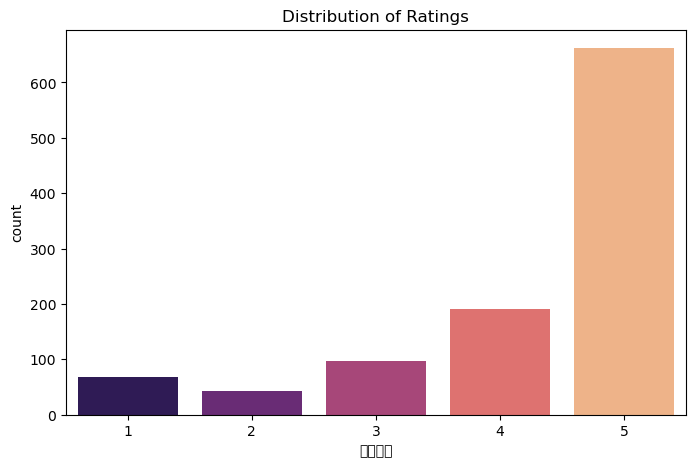

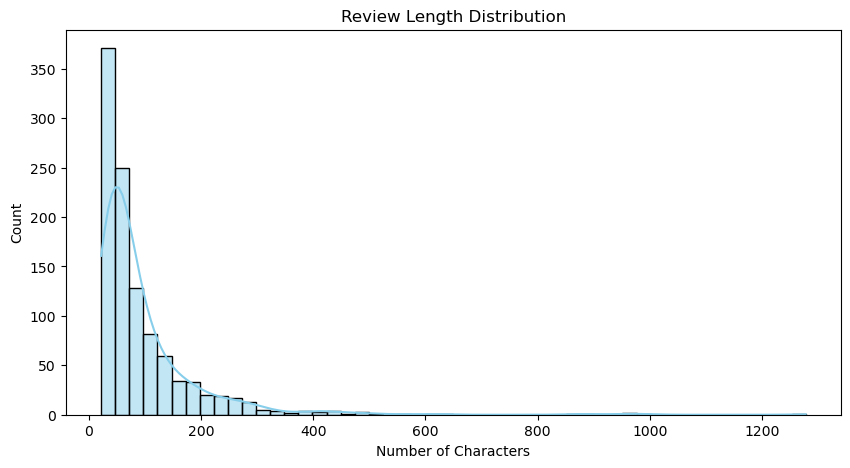

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1. 데이터 로드
df = pd.read_csv('khu_all_reviews_accumulated.csv')

# --- [기본 정보 확인] ---
print("✅ 데이터 모양 (행, 열):", df.shape)
print("\n✅ 컬럼별 데이터 타입 및 결측치:")
print(df.info())

# --- [통계 데이터 확인] ---
print("\n✅ 수치형 데이터 기초 통계:")
display(df.describe())

# --- [상세 분석 1: 과목별 리뷰 개수 상위 20개] ---
print("\n✅ 리뷰가장 많은 과목 Top 20:")
course_counts = df['강의명'].value_counts().head(20)
display(course_counts)

# --- [상세 분석 2: 과목별 평균 평점 (리뷰 5개 이상인 과목만)] ---
print("\n✅ 실제 평점이 높은 과목 (리뷰 5개 이상 기준):")
course_stats = df.groupby('강의명').agg({'개별평점': ['mean', 'count']})
course_stats.columns = ['평균평점', '리뷰개수']
top_rated = course_stats[course_stats['리뷰개수'] >= 5].sort_values(by='평균평점', ascending=False)
display(top_rated.head(10))

# --- [상세 분석 3: 수강시기별 리뷰 분포] ---
print("\n✅ 수강시기별 데이터 분포:")
display(df['수강시기'].value_counts())

# --- [텍스트 데이터 분석: 리뷰 길이] ---
df['length'] = df['서술평'].str.len()
print("\n✅ 리뷰 길이 통계 (글자 수):")
display(df['length'].describe())

# --- [시각화: 한글 깨짐 방지 설정 필요시 아래 주석 해제] ---
# plt.rcParams['font.family'] = 'Malgun Gothic' # 윈도우용
# plt.rcParams['axes.unicode_minus'] = False

# 1. 평점 분포 시각화
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='개별평점', palette='magma')
plt.title('Distribution of Ratings')
plt.show()

# 2. 리뷰 길이 분포 시각화 (히스토그램)
plt.figure(figsize=(10, 5))
sns.histplot(df['length'], bins=50, kde=True, color='skyblue')
plt.title('Review Length Distribution')
plt.xlabel('Number of Characters')
plt.show()

In [2]:
# 앞뒤 공백을 제거(strip)했을 때 빈 문자열('')이 되는 행 찾기
#
empty_text_df = df[df['서술평'].str.strip() == ""]

print(f"❌ 내용 없는 공백 리뷰 개수: {len(empty_text_df)}")
display(empty_text_df)

❌ 내용 없는 공백 리뷰 개수: 0


,강의명,전체평균평점,개별평점,수강시기,서술평,length
